In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
from tqdm import tqdm
import gdsfactory as gf

from DirectionalCoupler_Pulley import DirectionalCoupler_Pulley

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory
import addcopyfighandler

total_start = time.time()

# ----------------------------------------------------------------------------------
# Lumerical API path (uncomment for your machine) 
# ----------------------------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  # QP5
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP3
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP2

# ----------------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------------
WORKDIR   = Path().resolve()        # D:\...\scripts\directional_coupler
REPO_ROOT = WORKDIR.parents[1]     # D:\Ligentic_NU_1_TapeOut_April2026
os.chdir(WORKDIR)

data_save_dir = REPO_ROOT / "results_data" / "Data_directional_coupler_Pulley"
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORKDIR)
print("Data save   :", data_save_dir)

Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\directional_coupler
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_directional_coupler_Pulley


In [2]:
#------------------------------------------------------------
# LUMERICAL SESSION
#------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  
import lumapi as lm

try:
    f.redraw()
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()

if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session.")

LumFileName = "DirCoup_MultiSweep_Pulley.lms"
LumFilePath = str(WORKDIR / LumFileName)
f.save(LumFilePath)

f.switchtolayout()
f.selectall()
f.delete()

Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [3]:
#------------------------------------------------------------
# PARAMETERS 
#------------------------------------------------------------
LambdaStart    = 1540E-9
LambdaStop     = 1560E-9

Height         = 800E-9
XLength        = 10E-6
YLength        = 10E-6

Material           = "Si3N4 (Silicon Nitride) - Luke"
Index              = 2        # optional, used if material = '<Object defined dielectric>'
BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 500E-12
FrequencyPoints    = 200

print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 200


# Test Setup

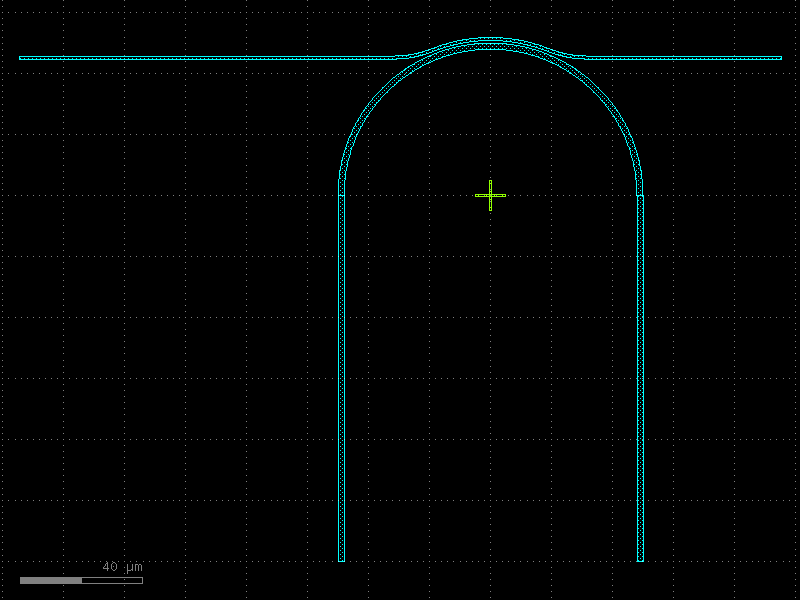

In [4]:
gf.clear_cache()

DC_Pulley = gf.Component("DC_Pulley")

DC_P = DC_Pulley << DirectionalCoupler_Pulley(TotLengthX = 300.0,
    InLengthX = 120.0,
    Radius = 50.0,
    WgWidth = 1.0,
    RingWgWidth = 2.0,
    Gap = 0.85,
    ThetaC = 40.0,
    BendRadiusIO = 25.0,
    Euler = 1,
    Layer = (2, 0),)

DC_Pulley.write_gds("DC_Pulley_test.gds")
DC_Pulley.plot()

In [5]:
f.gdsimport("DC_Pulley_test.gds", "DC_Pulley" ,"2:0", Material, 0, Height)


4.0

# Sweep

In [6]:
#------------------------------------------------------------
# HELPER FUNCTIONS
#------------------------------------------------------------
def start_section(name):
    tqdm.write(f"🏃 {name}...")
    return time.time()

def end_section(start):
    tqdm.write(f"✅ {time.time() - start:.1f}s")
#------------------------------------------------------------
# SWEEP LISTS
#------------------------------------------------------------
RingRadii    = np.array([25]) * 1E-6
RingWgWidths = np.array([1.6]) * 1E-6
WgWidths     = np.array([1.0]) * 1E-6
Eulers       = [0, 1]
Theta_Cs     = np.array([10,60])
Gaps         = np.array(np.arange(400, 1250, 50)) * 1E-9

#------------------------------------------------------------
# MULTI-DIMENSIONAL SWEEP
#------------------------------------------------------------
for Radius in tqdm(RingRadii, desc="Radius sweep"):

    csv_path = data_save_dir / f"Kappa2_vs_gap_Pulley_R{Radius*1e6:.0f}um.csv"
    if csv_path.exists():
        all_results = pd.read_csv(csv_path).to_dict('records')
        print(f"Loaded {len(all_results)} existing rows from {csv_path}")
    else:
        all_results = []
        print("No existing CSV found — starting fresh.")

    for RingWgWidth in tqdm(RingWgWidths, desc="  RingWgWidth sweep", leave=False):
        for WgWidth in tqdm(WgWidths, desc="    WgWidth sweep", leave=False):
            for Euler in tqdm(Eulers, desc="      Euler sweep", leave=False):
                for ThetaC in tqdm(Theta_Cs, desc="        ThetaC sweep", leave=False):
                    for Gap in tqdm(Gaps, desc="          Gap sweep", leave=False):

                        f.switchtolayout()
                        f.selectall()
                        f.delete()

                        tag = f"R{Radius*1e6:.0f}um_RW{RingWgWidth*1e9:.0f}nm_W{WgWidth*1e9:.0f}nm_E{Euler}_Th{ThetaC:.0f}_G{Gap*1e9:.0f}nm"
                        print(f"--- {tag} ---")
                        t = start_section("Geometry Setup")

                        #------------------------------------------------------------
                        # GDS GENERATION
                        #------------------------------------------------------------
                        gf.clear_cache()

                        dc = DirectionalCoupler_Pulley(
                            TotLengthX   = 200.0,
                            InLengthX    = 60.0,
                            Radius       = Radius * 1e6,        # m → µm
                            WgWidth      = WgWidth * 1e6,
                            RingWgWidth  = RingWgWidth * 1e6,
                            Gap          = Gap * 1e6,
                            ThetaC       = ThetaC,
                            BendRadiusIO = 25.0,
                            Euler        = Euler,
                            Layer        = (2, 0),
                        )

                        gds_path = str(WORKDIR / "DC_Pulley_sweep.gds")
                        dc.write_gds(gds_path)

                        #------------------------------------------------------------
                        # GDS IMPORT INTO LUMERICAL
                        #------------------------------------------------------------
                        f.gdsimport(gds_path, dc.name, "2:0", Material, 0, Height)

                        #------------------------------------------------------------
                        # BOUNDING BOX (µm → m)
                        #------------------------------------------------------------
                        bbox = dc.bbox()
                        x_min = bbox.left * 1e-6
                        x_max = bbox.right * 1e-6
                        y_min = bbox.bottom * 1e-6
                        y_max = bbox.top * 1e-6

                        margin = (LambdaStart + LambdaStop) / 2
                        x_span = (x_max - x_min) - 10 * margin
                        y_span = (y_max - y_min) + 2 * margin

                        x_left  = x_min + margin
                        x_right = x_max - margin
                        y_up    = y_max + margin
                        y_down  = y_min + 20*margin

                        X0 = 0
                        Y0 = Radius + 0*margin

                        ports = {p.name: (p.dcenter[0] * 1e-6, p.dcenter[1] * 1e-6) for p in dc.ports}
                        IN_offsetX = 14E-6  # inward offset from port
                        TH_offsetX = IN_offsetX
                        CR_offsetY = 60E-6 #InlenghtX
                        BS_offsetY = CR_offsetY

                        SourcePosX = ports["IN"][0] + IN_offsetX
                        SourcePosY = ports["IN"][1]

                        TH_PosX = ports["TH"][0] - TH_offsetX
                        TH_PosY = ports["TH"][1]

                        CR_PosX = ports["CR"][0]
                        CR_PosY = ports["CR"][1] + CR_offsetY

                        #------------------------------------------------------------
                        # varFDTD
                        #------------------------------------------------------------
                        f.addvarfdtd()
                        f.set("simulation time", SimulationTime)
                        f.set("x", 0)
                        f.set("y",0)
                        f.set("x0", X0)
                        f.set("y0", Y0)
                        f.set("x span", x_span)
                        f.set("y max", y_up)
                        f.set("y min", y_down)
                        f.set("z", Height / 2)
                        f.set("z span", 8 * Height)
                        f.set("background material", BackgroundMaterial)
                        f.set("set simulation bandwidth", 1)
                        f.set("bandwidth", "broadband")
                        f.set("simulation wavelength min", LambdaStart)
                        f.set("simulation wavelength max", LambdaStop)
                        f.set("auto shutoff min", 1E-5)

                        f.set("x min bc", "PML")
                        f.set("x max bc", "PML")
                        f.set("y min bc", "PML")
                        f.set("y max bc", "PML")
                        f.set("z min bc", "PML")
                        f.set("z max bc", "PML")

                        #------------------------------------------------------------
                        # SOURCE — at IN port, inject +x
                        #------------------------------------------------------------
                        f.addmodesource()
                        f.set("name", "ModeSource")
                        f.set("x", SourcePosX)
                        f.set("y", SourcePosY)
                        f.set("y span", 3 * WgWidth)
                        f.set("injection axis", "x-axis")
                        f.set("direction", "Forward")
                        f.set("amplitude", 1.0)
                        f.set("phase", 0)
                        f.set("mode selection", "fundamental mode")
                        f.set("set wavelength", 1)
                        f.set("wavelength start", LambdaStart)
                        f.set("wavelength stop", LambdaStop)

                        #------------------------------------------------------------
                        # MONITOR: Through
                        #------------------------------------------------------------

                        f.adddftmonitor()
                        f.set("name", "TH")
                        f.set("monitor type", "Linear Y")
                        f.set("x", TH_PosX)
                        f.set("y", TH_PosY)
                        f.set("y span", 3 * WgWidth)
                        f.set("z", Height / 2)
                        f.set("override global monitor settings", 1)
                        f.set("use source limits", 1)
                        f.set("frequency points", FrequencyPoints)

                        #------------------------------------------------------------
                        # MONITOR: Cross
                        #------------------------------------------------------------

                        f.adddftmonitor()
                        f.set("name", "CR")
                        f.set("monitor type", "Linear X")
                        f.set("x", CR_PosX)
                        f.set("y", CR_PosY)
                        f.set("x span", 3 * RingWgWidth)
                        f.set("z", Height / 2)
                        f.set("override global monitor settings", 1)
                        f.set("use source limits", 1)
                        f.set("frequency points", FrequencyPoints)

                        
                        end_section(t)

                        #------------------------------------------------------------
                        # MONITOR: Field
                        #------------------------------------------------------------
                        f.adddftmonitor()
                        f.set("name", "Field Monitor")
                        f.set("monitor type", "2D Z-normal")
                        f.set("x", X0)
                        f.set("x span", 2*Radius)
                        f.set("y", Radius/2+Gap+margin)
                        f.set("y span", 1*Radius)
                        f.set("z", Height / 2)
                        f.set("override global monitor settings", 1)
                        f.set("use wavelength spacing", 1)
                        f.set("wavelength center", 1550E-9)
                        f.set("wavelength span", 1E-9)
                        f.set("frequency points", 1)

                        end_section(t)

                        #------------------------------------------------------------
                        # Run
                        #------------------------------------------------------------
                        t = start_section("Running solver")
                        f.run()
                        end_section(t)

                        #------------------------------------------------------------
                        # Extract Results
                        #------------------------------------------------------------
                        try:
                            T_TH = f.getresult("TH", "T")
                            T_CR = f.getresult("CR", "T")

                            Tx_Through  = np.abs(T_TH["T"].flatten())
                            Tx_Cross    = np.abs(T_CR["T"].flatten())
                            Wavelength  = T_TH["lambda"].flatten()
                            # ... rest of extraction, plotting, CSV append
                        except Exception as e:
                            print(f"  ⚠ SKIPPED {tag}: {e}")
                            continue


                        Tx_total_out = Tx_Through + Tx_Cross

                        idx_1550        = np.argmin(np.abs(Wavelength - 1550e-9))
                        kappa_sq_1550   = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
                        loss_dB_1550    = -10 * np.log10(np.abs(Tx_total_out[idx_1550]))

                        print(f"  κ²={kappa_sq_1550:.4f} | Loss={loss_dB_1550:.2f} dB")

                        #------------------------------------------------------------
                        # E-field plot (save only, no show)
                        #------------------------------------------------------------
                        E_field    = f.getresult("Field Monitor", "E")
                        idx_1550_E = np.argmin(np.abs(E_field['lambda'].flatten() - 1550e-9))

                        fig_path = data_save_dir / f"Efield_DirCoup_{tag}.png"

                        try:
                            x = E_field['x'].flatten() * 1e6
                            y = E_field['y'].flatten() * 1e6
                            plt.figure(figsize=(6,4))
                            plt.imshow(np.abs(E_field['E'][:,:,0,idx_1550_E,1]).T**2,
                                    aspect='auto', cmap='hot', origin='lower',
                                    extent=[x.min(), x.max(), y.min(), y.max()])
                            plt.xlabel('x (µm)')
                            plt.ylabel('y (µm)')
                            plt.colorbar(label='|Ey|²')
                            plt.title(f'Field Profile at 1550nm | {tag}')
                            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
                            plt.close('all')
                        except Exception as e:
                            print(f"  E-field save failed: {e}")
                            plt.close('all')

                        #------------------------------------------------------------
                        # Append to results (replace if exists)
                        #------------------------------------------------------------
                        new_row = {
                            "R"          : round(Radius*1e6, 3),
                            "RW"         : round(RingWgWidth*1e9, 3),
                            "W"          : round(WgWidth*1e9, 3),
                            "E"          : Euler,
                            "Th"         : ThetaC,
                            "G"          : round(Gap*1e9, 3),
                            "Kx"         : kappa_sq_1550,
                            "Loss"       : loss_dB_1550,
                            "Tx_Cross"   : Tx_Cross[idx_1550],
                            "Tx_Through" : Tx_Through[idx_1550],
                        }

                        key = ("R", "RW", "W", "E", "Th", "G")
                        match = next((i for i, r in enumerate(all_results)
                                    if all(r[k] == new_row[k] for k in key)), None)
                        if match is not None:
                            all_results[match] = new_row
                            print(f"  Updated existing row | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")
                        else:
                            all_results.append(new_row)
                            print(f"  New row added | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")

                        pd.DataFrame(all_results).to_csv(csv_path, index=False)

#------------------------------------------------------------
# MASTER CSV
#------------------------------------------------------------
df = pd.DataFrame(all_results)
print(df)
print(f"\nMaster CSV saved to {csv_path}")

Radius sweep:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded 36 existing rows from D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_directional_coupler_Pulley\Kappa2_vs_gap_Pulley_R25um.csv




                                                  


                                               




                                                           
                                                       



                                               






Radius sweep:   0%|          | 0/1 [00:00<?, ?it/s]




--- R25um_RW1600nm_W1000nm_E0_Th10_G400nm ---
🏃 Geometry Setup...




                                                  


                                               




                                                           
                                                       



                                               






Radius sweep:   0%|          | 0/1 [00:01<?, ?it/s]




...

✅ 1.0s




                                                  


                                                                 
                                                       



                                                        




                                                     


Radius sweep:   0%|          | 0/1 [19:31<?, ?it/s]








                                                  


                                                                 
                                                       



                                                        




                                                     


Radius sweep:   0%|          | 0/1 [19:31<?, ?it/s]








✅ 1.2s
🏃 Running solver...




                                                  


                                                                 
                                                       



                                                        




                                                     


Radius sweep:   0%|          | 0/1 [19:40<?, ?it/s]


























Radius sweep: 100%|██████████| 1/1 [19:40<00:00, 1180.92s/it]

✅ 9.5s
  ⚠ SKIPPED R25um_RW1600nm_W1000nm_E1_Th60_G1200nm: "Can not find result 'T' in the result provider 'TH'"
       R      RW       W  E  Th       G        Kx      Loss  Tx_Cross  \
0   25.0  1600.0  1000.0  0  20   400.0  0.052459  0.099656  0.051269   
1   25.0  1600.0  1000.0  1  20   400.0  0.042075  0.005097  0.042026   
2   25.0  1600.0  1000.0  0  30   400.0  0.052160  0.036383  0.051725   
3   25.0  1600.0  1000.0  0  30   450.0  0.035383  0.034233  0.035105   
4   25.0  1600.0  1000.0  0  30   500.0  0.024192  0.031967  0.024015   
5   25.0  1600.0  1000.0  0  30   550.0  0.016774  0.029124  0.016662   
6   25.0  1600.0  1000.0  0  30   600.0  0.011916  0.028135  0.011839   
7   25.0  1600.0  1000.0  0  30   650.0  0.008332  0.027397  0.008280   
8   25.0  1600.0  1000.0  0  30   700.0  0.005907  0.027452  0.005870   
9   25.0  1600.0  1000.0  0  30   750.0  0.004207  0.026290  0.004182   
10  25.0  1600.0  1000.0  0  30   800.0  0.002942  0.026815  0.002924   
11  25.0  1

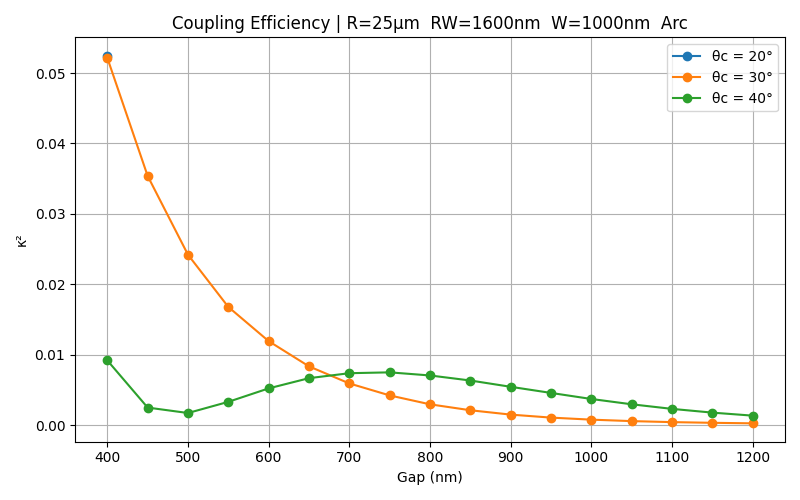

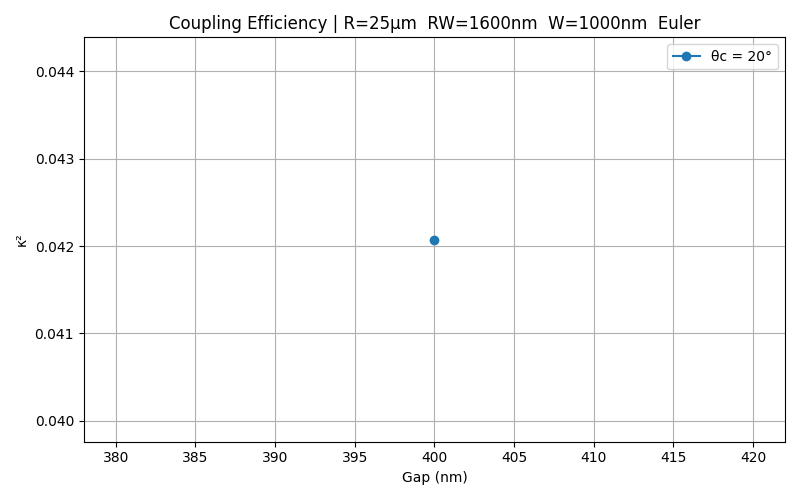

In [7]:
#------------------------------------------------------------
# LOAD & PLOT RESULTS
#------------------------------------------------------------
df = pd.read_csv(data_save_dir / f"Kappa2_vs_gap_Pulley_R{RingRadii[0]*1e6:.0f}um.csv")

groups = df.groupby(["R", "RW", "W"]).groups.keys()

for (R, RW, W) in groups:
    mask = (df["R"] == R) & (df["RW"] == RW) & (df["W"] == W)
    sub  = df[mask]

    for E in sorted(sub["E"].unique()):
        sub_e = sub[sub["E"] == E]

        plt.figure(figsize=(8, 5))
        for Th in sorted(sub_e["Th"].unique()):
            m = sub_e["Th"] == Th
            plt.plot(sub_e[m]["G"], sub_e[m]["Kx"], '-o', linewidth=1.5,
                    label=f'θc = {Th:.0f}°')

        euler_str = "Euler" if E == 1 else "Arc"
        plt.xlabel('Gap (nm)')
        plt.ylabel('κ²')
        plt.title(f'Coupling Efficiency | R={R:.0f}µm  RW={RW:.0f}nm  W={W:.0f}nm  {euler_str}')
        plt.legend(loc='best')
        plt.grid()
        plt.tight_layout()
        plt.savefig(data_save_dir / f"Kx_vs_gap_R{R:.0f}um_RW{RW:.0f}nm_W{W:.0f}nm_E{E}.png",
                    dpi=150, bbox_inches='tight')
        mplcursors.cursor(hover=True)
        disconnect_zoom = zoom_factory(plt.gca())
        # plt.show()